PCA and K-means Clustering

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Principal Component Analysis (PCA)

In [2]:
df = pd.read_csv('diabetes_012_health_indicators_BRFSS2015.csv')

In [3]:
df['diabetes_status'] = df['Diabetes_012'].replace({0:0, 1:1, 2:1})
target = 'diabetes_status'

In [4]:
features = [
    'BMI',
    'HighBP',
    'Age',
    'Education',
    'GenHlth',
    'PhysHlth',
    'HighChol',
    'DiffWalk',
    'HeartDiseaseorAttack'
]

In [5]:
X = df[features]
y = df[target]

In [6]:
X = pd.get_dummies(
    X,
    columns=['Education'],
    drop_first=True
)

In [7]:
X.head()

,BMI,HighBP,Age,GenHlth,PhysHlth,HighChol,DiffWalk,HeartDiseaseorAttack,Education_2.0,Education_3.0,Education_4.0,Education_5.0,Education_6.0
0,40.0,1.0,9.0,5.0,15.0,1.0,1.0,0.0,False,False,True,False,False
1,25.0,0.0,7.0,3.0,0.0,0.0,0.0,0.0,False,False,False,False,True
2,28.0,1.0,9.0,5.0,30.0,1.0,1.0,0.0,False,False,True,False,False
3,27.0,1.0,11.0,2.0,0.0,0.0,0.0,0.0,False,True,False,False,False
4,24.0,1.0,11.0,2.0,0.0,1.0,0.0,0.0,False,False,False,True,False


In [8]:
X.columns

Index(['BMI', 'HighBP', 'Age', 'GenHlth', 'PhysHlth', 'HighChol', 'DiffWalk',
       'HeartDiseaseorAttack', 'Education_2.0', 'Education_3.0',
       'Education_4.0', 'Education_5.0', 'Education_6.0'],
      dtype='object')

In [9]:
# balance training set 
from sklearn.utils import resample

data = pd.concat([X, y], axis=1)

majority = data[data.diabetes_status == 0]
minority = data[data.diabetes_status == 1]

majority_downsampled = resample(
    majority,
    replace=False,
    n_samples=len(minority),
    random_state=42
)

balanced_data = pd.concat(
    [majority_downsampled, minority]
)

X = balanced_data.drop('diabetes_status', axis=1)
y = balanced_data['diabetes_status']

In [10]:
# Standardize the features 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[-0.81521677, -1.11487116,  0.14952236, ..., -0.61230223,
         1.59703253, -0.77037068],
       [ 0.3190213 ,  0.89696464, -0.19925118, ..., -0.61230223,
        -0.62616132,  1.2980764 ],
       [-0.24809773,  0.89696464,  0.14952236, ..., -0.61230223,
        -0.62616132,  1.2980764 ],
       ...,
       [-0.67343701,  0.89696464,  1.54461649, ..., -0.61230223,
        -0.62616132,  1.2980764 ],
       [-1.66589532,  0.89696464,  0.84706942, ..., -0.61230223,
        -0.62616132, -0.77037068],
       [-0.67343701,  0.89696464,  0.14952236, ..., -0.61230223,
        -0.62616132,  1.2980764 ]], shape=(79954, 13))

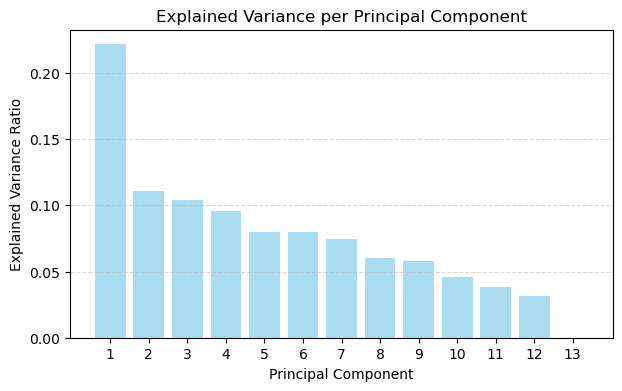

In [11]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Explained variance per component
explained_variance_ratio = pca.explained_variance_ratio_

# Plot explained variance per component
plt.figure(figsize=(7, 4))
plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, alpha=0.7, color='skyblue')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance per Principal Component')
plt.xticks(range(1, len(explained_variance_ratio) + 1))
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.show()


In [12]:
# Apply PCA and reduce components to explain at least 90% of  the variance
pca = PCA(n_components=0.90)
X_pca = pca.fit_transform(X_scaled)

print("Number of components selected:", pca.n_components_)

Number of components selected: 10


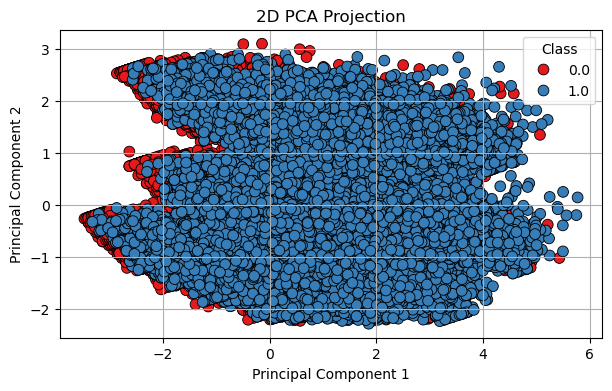

In [14]:
from mpl_toolkits.mplot3d import Axes3D

pca = PCA(n_components=2)  
X_pca_2d = pca.fit_transform(X_scaled)

plt.figure(figsize=(7, 4))
sns.scatterplot( x=X_pca_2d[:, 0], y=X_pca_2d[:, 1], hue=y,  palette='Set1', s=60,edgecolor='k')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('2D PCA Projection')
plt.legend(title='Class')
plt.grid(True)
plt.show()

# Logistic Regression with PCA

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, f1_score

# Split the PCA-transformed data
X_train, X_test, y_train, y_test = train_test_split(
    X_pca,
    y,
    test_size=0.2,
    random_state=42
)

logreg = LogisticRegression(max_iter=1000)

# Perform 5-cross validation 
accuracy_scores = cross_val_score(logreg, X_train, y_train, cv=5, scoring='accuracy')
f1_scores = cross_val_score(logreg, X_train , y_train, cv=5, scoring='f1_weighted')

print("Average CV Accuracy:", accuracy_scores.mean())
print("Average CV F1:", f1_scores.mean())


Average CV Accuracy: 0.7326267682642071
Average CV F1: 0.7325575779976378


In [19]:
# Train the final model on the full training set
logreg.fit(X_train, y_train)

# Make predictions on the testing set
y_pred = logreg.predict(X_test)

# Evaluate the model
test_accuracy = accuracy_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred, average='weighted')

print("Test Accuracy:", test_accuracy)
print("Test F1 Score:", test_f1)

Test Accuracy: 0.7267212807204052
Test F1 Score: 0.7267012438591549


# K-Means Clustering 

**K-Means Clustering on the Standardized Features**

In [44]:
# Select the features
X_cluster = df[features].copy()

# Standardize the features
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)


In [33]:
# Try k values from 1 to 10
inertias = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

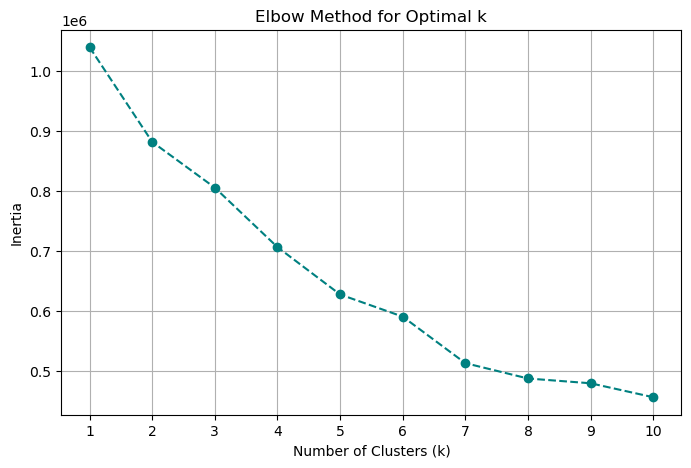

In [34]:
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker='o', linestyle='--', color='teal')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.grid(True)
plt.show()

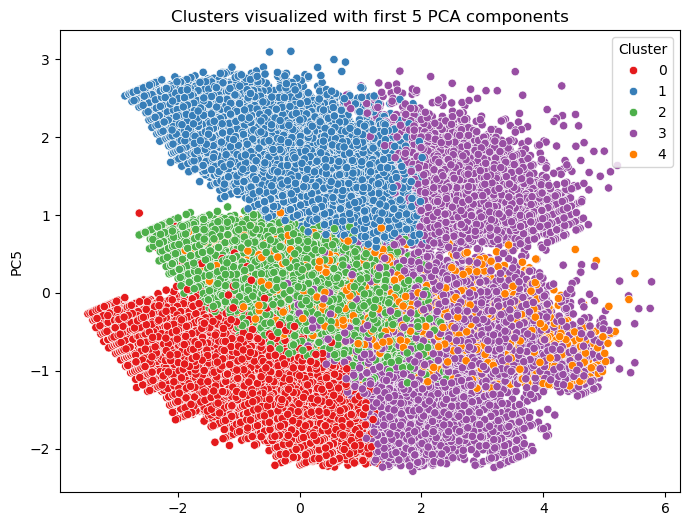

In [39]:
final_kmeans = KMeans(n_clusters=5, random_state=42)
cluster_labels = final_kmeans.fit_predict(X_scaled)

# 2D PCA for visualization
X_2D = X_pca[:, :2]

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_2D[:, 0], y=X_2D[:, 1], hue=cluster_labels, palette='Set1')
plt.title('Clusters visualized with first 5 PCA components')
plt.ylabel('PC5')
plt.legend(title='Cluster')
plt.show()


In [40]:
# Get cluster centers in standardized feature space
cluster_centers = final_kmeans.cluster_centers_

# Convert to a DataFrame for readability
centers_df = pd.DataFrame(cluster_centers, columns=X.columns)
centers_df

,BMI,HighBP,Age,GenHlth,PhysHlth,HighChol,DiffWalk,HeartDiseaseorAttack,Education_2.0,Education_3.0,Education_4.0,Education_5.0,Education_6.0
0,-0.218102,-0.259127,-0.151006,-0.488509,-0.384478,-0.155353,-0.413689,-0.212758,-0.104557,-0.227546,-0.612302,-0.626161,1.281322
1,-0.047846,-0.088649,-0.100955,-0.230185,-0.314722,-0.090443,-0.280784,-0.159076,-0.153776,-0.227546,-0.612302,1.597033,-0.770371
2,-0.030691,0.018712,0.053003,-0.065853,-0.303266,-0.032034,-0.221953,-0.124616,-0.153776,-0.227546,1.631487,-0.626161,-0.770371
3,0.489824,0.534579,0.323036,1.211000,1.494728,0.426044,1.361374,0.749147,0.665821,-0.227546,0.155205,0.044866,-0.294095
4,0.184698,0.288200,0.175840,0.591309,0.351870,0.178383,0.489611,0.199893,-0.153776,4.394715,-0.612302,-0.626161,-0.770371


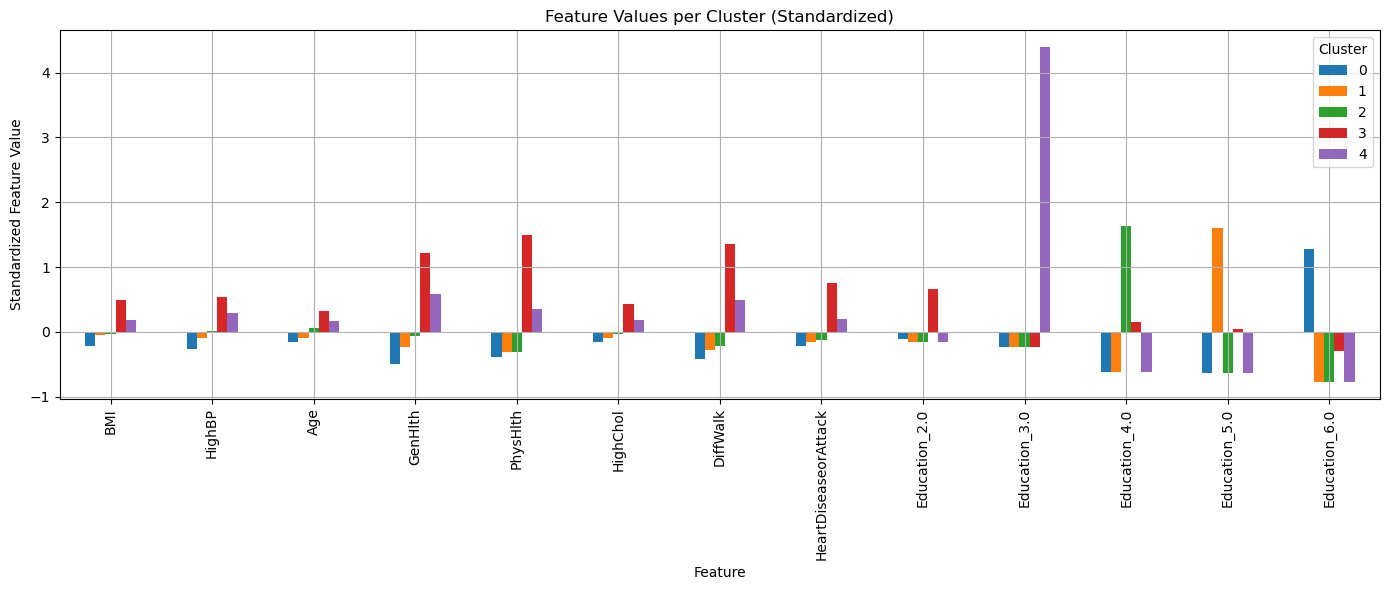

In [41]:
# Barplot for feature contributions per cluster
centers_df.T.plot(kind='bar', figsize=(14, 6))
plt.title('Feature Values per Cluster (Standardized)')
plt.ylabel('Standardized Feature Value')
plt.xlabel('Feature')
plt.xticks(rotation=90)
plt.grid(True)
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()


In [43]:
pd.Series(cluster_labels).value_counts().sort_index()

0    26917
1    18480
2    17244
3    13377
4     3936
Name: count, dtype: int64

**Cluster analysis**  
The K-Means analysis identified five clusters with different health and demographic profiles. Because the variables were standardized, positive centroid values indicate values above the overall mean, while negative values indicate values below the mean.

Cluster 0 represents a relatively lower-risk health profile, with below-average values across several health indicators and a strong representation of the Education_6.0 category.

Cluster 1 also shows a generally lower-risk profile, with below-average values for several health-related variables and a strong representation of Education_5.0.

Cluster 2 has a relatively average health profile, with most health indicators close to the overall mean. This cluster is strongly characterized by Education_4.0.

Cluster 3 represents the highest-risk health profile. It has above-average values for high blood pressure, poor general and physical health, high cholesterol, difficulty walking, and heart disease or heart attack.

Cluster 4 represents a moderately higher-risk profile, with above-average values for several health indicators. It is strongly characterized by the Education_3.0 category.

Overall, the clusters suggest that the dataset contains groups with noticeably different combinations of health characteristics and education categories. However, these clusters should be interpreted as descriptive groupings rather than evidence of causal relationships.
